In [1]:
!pip install pandas numpy tensorflow scikit-learn matplotlib seaborn nltk

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv(r"D:\collage\sem\Sem7\NLP project\financial_news_events.csv")

# Use "Headline" column as input text, "Sentiment" as label
df = df.dropna(subset=['Sentiment'])   # drop rows with missing sentiment
texts = df['Headline'].astype(str).tolist()
labels = pd.get_dummies(df['Sentiment']).values  # One-hot encode labels

# Tokenization
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_len = 100
X = pad_sequences(sequences, maxlen=max_len)
y = labels

# Split dataset: 50% training, 50% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Build model - FIXED ARCHITECTURE
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=128, input_length=max_len))
model.add(LSTM(128, return_sequences=True))  # Changed to True for stacked LSTM
model.add(Dropout(0.5))
model.add(LSTM(64, return_sequences=False))  # Last LSTM layer returns False
model.add(Dense(y.shape[1], activation='softmax'))  # dynamically adjust to number of sentiment classes

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

# Train the model on training set
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

model.save(r"D:\collage\sem\Sem7\NLP project\sentiment_lstm_model.h5")
print("Model saved successfully!")

# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy: 0.3408 - loss: 1.0997 - val_accuracy: 0.3294 - val_loss: 1.1000
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.3534 - loss: 1.0960 - val_accuracy: 0.3350 - val_loss: 1.1034
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - accuracy: 0.3948 - loss: 1.0887 - val_accuracy: 0.3273 - val_loss: 1.1145
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.4060 - loss: 1.0827 - val_accuracy: 0.3167 - val_loss: 1.1259
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.4074 - loss: 1.0798 - val_accuracy: 0.3125 - val_loss: 1.1216
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.4151 - loss: 1.0773 - val_accuracy: 0.3139 - val_loss: 1.1353
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.4137 - loss: 1.0765 - val_accuracy: 0.3041 - val_loss: 1.1270
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.4180 - loss: 1.0766 - val_accura

Model saved successfully!
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3139 - loss: 1.1332
Test Accuracy: 0.3139


In [3]:
from tensorflow.keras.models import load_model
# Load the saved model
model = load_model(r"D:\collage\sem\Sem7\NLP project\sentiment_lstm_model.h5")
print("Model loaded successfully!")

Model loaded successfully!


In [4]:
import random
import numpy as np

# Pick 5 random samples from the test set
num_samples = 10
indices = random.sample(range(X_test.shape[0]), num_samples)

for i in indices:
    x_sample = X_test[i].reshape(1, -1)  # reshape for model prediction
    y_true = y_test[i]
    y_pred = model.predict(x_sample, verbose=0)
    
    # Convert one-hot to labels
    true_label = df['Sentiment'].unique()[np.argmax(y_true)]
    pred_label = df['Sentiment'].unique()[np.argmax(y_pred)]
    
    print(f"Headline: {tokenizer.sequences_to_texts([X_test[i]])[0]}")
    print(f"Actual Sentiment: {true_label}")
    print(f"Predicted Sentiment: {pred_label}")
    print("-" * 50)


Headline: central bank governor signals potential shift in policy
Actual Sentiment: Positive
Predicted Sentiment: Neutral
--------------------------------------------------
Headline: utilities sector remains stable during market fluctuations
Actual Sentiment: Negative
Predicted Sentiment: Positive
--------------------------------------------------
Headline: asx 200 gains on strong export performance
Actual Sentiment: Positive
Predicted Sentiment: Neutral
--------------------------------------------------
Headline: utilities sector remains stable during market fluctuations
Actual Sentiment: Negative
Predicted Sentiment: Positive
--------------------------------------------------
Headline: massive stock buyback program announced by a consumer goods company
Actual Sentiment: Negative
Predicted Sentiment: Positive
--------------------------------------------------
Headline: retail sales report surpasses all forecasts
Actual Sentiment: Neutral
Predicted Sentiment: Neutral
------------------

In [9]:
# Ask user for a headline
user_input = input("Enter a news headline to predict sentiment: ")

# Preprocess input
seq = tokenizer.texts_to_sequences([user_input])
padded_seq = pad_sequences(seq, maxlen=max_len)

# Predict
pred = model.predict(padded_seq, verbose=0)
pred_label = df['Sentiment'].unique()[np.argmax(pred)]

print(f"Predicted Sentiment: {pred_label}")


Predicted Sentiment: Neutral


Predicting ON headline

In [6]:
!pip install nltk spacy

Defaulting to user installation because normal site-packages is not writeable


In [10]:
import nltk
import re
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Please install spaCy English model: python -m spacy download en_core_web_sm")
    nlp = None

def preprocess_text(text):
    """Preprocess text for better model performance"""
    if not isinstance(text, str):
        text = str(text)
    
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    
    try:
        tokens = word_tokenize(text)
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
        
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        
        return ' '.join(tokens)
    except:
        return text

def extract_entities(text):
    """Extract named entities from financial news"""
    if nlp is None:
        return {'PERSON': [], 'ORG': [], 'GPE': [], 'MONEY': [], 'PERCENT': [], 'DATE': []}
    
    doc = nlp(text)
    entities = {'PERSON': [], 'ORG': [], 'GPE': [], 'MONEY': [], 'PERCENT': [], 'DATE': []}
    
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text)
    
    return entities

print("NLP preprocessing functions loaded successfully!")

from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Mapping from sentiment to action
sentiment_to_action = {
    'Positive': 'Buy',
    'Neutral': 'Hold',
    'Negative': 'Sell'
}

# Function to predict action from a headline
def predict_action(headline, tokenizer, max_len=100):
    processed_headline = preprocess_text(headline)
    seq = tokenizer.texts_to_sequences([processed_headline])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(padded, verbose=0)
    sentiment_idx = np.argmax(pred)
    sentiment_classes = ['Negative', 'Neutral', 'Positive']
    predicted_sentiment = sentiment_classes[sentiment_idx]
    confidence = float(np.max(pred))
    action = sentiment_to_action[predicted_sentiment]
    entities = extract_entities(headline)
    
    return {
        'headline': headline,
        'processed_text': processed_headline,
        'sentiment': predicted_sentiment,
        'action': action,
        'confidence': confidence,
        'entities': entities
    }

# Example usage
headline = input("Enter a news headline to predict action: ")
result = predict_action(headline, tokenizer)

# Display results
print(f"Headline: {result['headline']}")
print(f"Processed Text: {result['processed_text']}")
print(f"Predicted Sentiment: {result['sentiment']}")
print(f"Recommended Action: {result['action']}")
print(f"Confidence: {result['confidence']:.4f}")
confidence_percent = result['confidence'] * 100
print(f"Confidence in percentage: {confidence_percent:.2f}%")


Please install spaCy English model: python -m spacy download en_core_web_sm
NLP preprocessing functions loaded successfully!
Headline: Gold rates today: Gold price reaches record high; touches Rs 1,27,500 per 10 grams
Processed Text: gold rates today gold price reaches record high touches rs per grams
Predicted Sentiment: Negative
Recommended Action: Sell
Confidence: 0.3532
Confidence in percentage: 35.32%


=== MODEL EVALUATION METRICS ===

Training Accuracy: 0.4299 (42.99%)
Validation Accuracy: 0.3139 (31.39%)
Test Accuracy: 0.3139 (31.39%)
F1-Score (Macro): 0.3130
F1-Score (Weighted): 0.3139

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Neutral       0.36      0.34      0.35       495
    Positive       0.30      0.34      0.32       470
    Negative       0.28      0.26      0.27       462

    accuracy                           0.31      1427
   macro avg       0.31      0.31      0.31      1427
weighted avg       0.31      0.31      0.31      1427


=== CONFUSION MATRIX ===


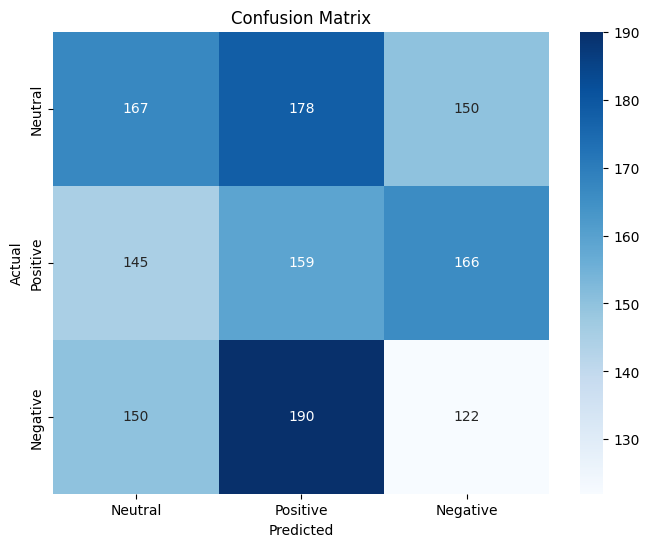


=== SUMMARY TABLE ===
             Metric  Value Percentage
  Training Accuracy 0.4299     42.99%
Validation Accuracy 0.3139     31.39%
      Test Accuracy 0.3139     31.39%
   F1-Score (Macro) 0.3130     31.30%
F1-Score (Weighted) 0.3139     31.39%


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns

# Get training history (you'll need to modify the training cell to capture history)
# For now, let's evaluate the trained model

print("=== MODEL EVALUATION METRICS ===\n")

# 1. Training Accuracy (from training data)
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# 2. Validation/Test Accuracy (same in your case since you used test set for validation)
val_loss, val_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# 3. Test Accuracy (same as validation in your setup)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# 4. F1-Score calculation
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculate F1-score (macro average for multi-class)
f1_macro = f1_score(y_true_classes, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")

# Detailed classification report
print("\n=== DETAILED CLASSIFICATION REPORT ===")
sentiment_labels = df['Sentiment'].unique()
print(classification_report(y_true_classes, y_pred_classes, target_names=sentiment_labels))

# Confusion Matrix
print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Summary table
print("\n=== SUMMARY TABLE ===")
metrics_summary = {
    'Metric': ['Training Accuracy', 'Validation Accuracy', 'Test Accuracy', 'F1-Score (Macro)', 'F1-Score (Weighted)'],
    'Value': [f"{train_accuracy:.4f}", f"{val_accuracy:.4f}", f"{test_accuracy:.4f}", f"{f1_macro:.4f}", f"{f1_weighted:.4f}"],
    'Percentage': [f"{train_accuracy*100:.2f}%", f"{val_accuracy*100:.2f}%", f"{test_accuracy*100:.2f}%", f"{f1_macro*100:.2f}%", f"{f1_weighted*100:.2f}%"]
}

summary_df = pd.DataFrame(metrics_summary)
print(summary_df.to_string(index=False))